# **EDA: FSD50K**

**Fuente:** https://zenodo.org/records/4060432

Este dataset contiene **51.197 fragmentos** de audio de Freesound distribuidos de forma desigual en 200 clases extraídas de la ontología AudioSet. FSD50K fue creado en el Grupo de Tecnología Musical (MTG) de la Universitat Pompeu Fabra. Incluye:
- `FSD50K.dev_audio`: set de desarrollo (~40k clips).
- `FSD50K.eval_audio`: set de evaluación (~10k clips).
- Archivos de metadatos CSV con etiquetas, splits y vocabulario.

## **1. Instalación y configuración**

In [1]:
import os
import zipfile
import tarfile
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import librosa
import librosa.display
import soundfile as sf
from IPython.display import Audio, display
from tqdm.notebook import tqdm

# Estilo
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.labelsize': 12
})

print('Librerías importadas.')

Librerías importadas.


## **2. Descarga de metadatos desde Zenodo**

- Se descargan automáticamente los dos ZIPs de metadatos (~pocos MB cada uno):
  - `FSD50K.ground_truth.zip` --> `dev.csv`, `eval.csv`, `vocabulary.csv` (las 50K filas)
  - `FSD50K.metadata.zip` --> duración, sample rate, licencia por clip.
- FSD50K pesa ~30 GB en total.

In [2]:
import os, zipfile, urllib.request

BASE_DIR = '/content/FSD50K'
os.makedirs(BASE_DIR, exist_ok=True)

ZENODO_BASE = 'https://zenodo.org/records/4060432/files'

# Solo los dos ZIPs de metadatos (ligeros)
META_ZIPS = {
    'FSD50K.ground_truth.zip': f'{ZENODO_BASE}/FSD50K.ground_truth.zip?download=1',
    'FSD50K.metadata.zip': f'{ZENODO_BASE}/FSD50K.metadata.zip?download=1',
}

def download_if_missing(fname, url, dest_dir):
    dest = os.path.join(dest_dir, fname)
    if os.path.exists(dest):
        print(f'Ya existe: {fname}')
        return dest
    print(f'Descargando {fname} ...', end=' ', flush=True)
    urllib.request.urlretrieve(url, dest)
    size_mb = os.path.getsize(dest) / 1e6
    print(f'{size_mb:.1f} MB')
    return dest

def extract_if_missing(zip_path, dest_dir):
    folder = os.path.join(dest_dir, os.path.basename(zip_path).replace('.zip',''))
    if os.path.exists(folder):
        print(f'Ya extraído: {os.path.basename(folder)}')
        return folder
    print(f'Extrayendo {os.path.basename(zip_path)} ...', end=' ', flush=True)
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(dest_dir)
    print('OK.')
    return folder

print('Descargando metadatos FSD50K desde Zenodo...')
for fname, url in META_ZIPS.items():
    zpath = download_if_missing(fname, url, BASE_DIR)
    extract_if_missing(zpath, BASE_DIR)

# Rutas finales
GT_DIR = os.path.join(BASE_DIR, 'FSD50K.ground_truth')
META_DIR = os.path.join(BASE_DIR, 'FSD50K.metadata')

# Audio
DEV_AUDIO_DIR = os.path.join(BASE_DIR, 'FSD50K.dev_audio')
EVAL_AUDIO_DIR = os.path.join(BASE_DIR, 'FSD50K.eval_audio')

print('\nEstado de directorios:')
for label, d in [('ground_truth', GT_DIR), ('metadata', META_DIR),
                 ('dev_audio', DEV_AUDIO_DIR), ('eval_audio', EVAL_AUDIO_DIR)]:
    estado = 'Disponible' if os.path.exists(d) else 'No disponible.'
    print(f'{estado} - {label}')

Descargando metadatos FSD50K desde Zenodo...
Descargando FSD50K.ground_truth.zip ... 0.3 MB
Extrayendo FSD50K.ground_truth.zip ... OK.
Descargando FSD50K.metadata.zip ... 6.7 MB
Extrayendo FSD50K.metadata.zip ... OK.

Estado de directorios:
Disponible - ground_truth
Disponible - metadata
No disponible. - dev_audio
No disponible. - eval_audio


## **3. Carga de metadatos**

In [3]:
# Ground truth CSVs
dev_gt_path = os.path.join(GT_DIR, 'dev.csv')
eval_gt_path = os.path.join(GT_DIR, 'eval.csv')
vocab_path = os.path.join(GT_DIR, 'vocabulary.csv')

df_dev = pd.read_csv(dev_gt_path)
df_eval = pd.read_csv(eval_gt_path)
df_vocab = pd.read_csv(vocab_path, header=None, names=['id', 'label', 'mid'])

print(f'\nShape dev: {df_dev.shape}')
print(f'Shape eval: {df_eval.shape}')
print(f'Shape vocab: {df_vocab.shape}')


Shape dev: (40966, 4)
Shape eval: (10231, 3)
Shape vocab: (200, 3)


In [4]:
print('Dev set (primeras filas)')
display(df_dev.head())

Dev set (primeras filas)


,fname,labels,mids,split
0,64760,"Electric_guitar,Guitar,Plucked_string_instrume...","/m/02sgy,/m/0342h,/m/0fx80y,/m/04szw,/m/04rlf",train
1,16399,"Electric_guitar,Guitar,Plucked_string_instrume...","/m/02sgy,/m/0342h,/m/0fx80y,/m/04szw,/m/04rlf",train
2,16401,"Electric_guitar,Guitar,Plucked_string_instrume...","/m/02sgy,/m/0342h,/m/0fx80y,/m/04szw,/m/04rlf",train
3,16402,"Electric_guitar,Guitar,Plucked_string_instrume...","/m/02sgy,/m/0342h,/m/0fx80y,/m/04szw,/m/04rlf",train
4,16404,"Electric_guitar,Guitar,Plucked_string_instrume...","/m/02sgy,/m/0342h,/m/0fx80y,/m/04szw,/m/04rlf",train


In [5]:
print('Dev set (últimas filas)')
display(df_dev.tail())

Dev set (últimas filas)


,fname,labels,mids,split
40961,102863,"Fowl,Livestock_and_farm_animals_and_working_an...","/m/025rv6n,/m/0ch8v,/m/0jbk",train
40962,389607,"Fowl,Livestock_and_farm_animals_and_working_an...","/m/025rv6n,/m/0ch8v,/m/0jbk",train
40963,90091,"Fowl,Livestock_and_farm_animals_and_working_an...","/m/025rv6n,/m/0ch8v,/m/0jbk",train
40964,244718,"Fowl,Livestock_and_farm_animals_and_working_an...","/m/025rv6n,/m/0ch8v,/m/0jbk",train
40965,24061,"Fowl,Livestock_and_farm_animals_and_working_an...","/m/025rv6n,/m/0ch8v,/m/0jbk",train


In [6]:
print('Eval set (primeras filas)')
display(df_eval.head())

Eval set (primeras filas)


,fname,labels,mids
0,37199,"Electric_guitar,Guitar,Plucked_string_instrume...","/m/02sgy,/m/0342h,/m/0fx80y,/m/04szw,/m/04rlf"
1,175151,"Electric_guitar,Guitar,Plucked_string_instrume...","/m/02sgy,/m/0342h,/m/0fx80y,/m/04szw,/m/04rlf"
2,253463,"Electric_guitar,Guitar,Plucked_string_instrume...","/m/02sgy,/m/0342h,/m/0fx80y,/m/04szw,/m/04rlf"
3,329838,"Electric_guitar,Guitar,Plucked_string_instrume...","/m/02sgy,/m/0342h,/m/0fx80y,/m/04szw,/m/04rlf"
4,1277,"Electric_guitar,Guitar,Plucked_string_instrume...","/m/02sgy,/m/0342h,/m/0fx80y,/m/04szw,/m/04rlf"


In [7]:
print('Eval set (últimas filas)')
display(df_eval.tail())

Eval set (últimas filas)


,fname,labels,mids
10226,266616,Livestock_and_farm_animals_and_working_animals...,"/m/0ch8v,/m/0jbk"
10227,137745,"Fowl,Livestock_and_farm_animals_and_working_an...","/m/025rv6n,/m/0ch8v,/m/0jbk"
10228,418509,"Fowl,Livestock_and_farm_animals_and_working_an...","/m/025rv6n,/m/0ch8v,/m/0jbk"
10229,76133,"Fowl,Livestock_and_farm_animals_and_working_an...","/m/025rv6n,/m/0ch8v,/m/0jbk"
10230,106346,"Fowl,Livestock_and_farm_animals_and_working_an...","/m/025rv6n,/m/0ch8v,/m/0jbk"


In [8]:
print('Vocab set (primeras filas)')
display(df_vocab.head())

Vocab set (primeras filas)


,id,label,mid
0,0,Accelerating_and_revving_and_vroom,/m/07q2z82
1,1,Accordion,/m/0mkg
2,2,Acoustic_guitar,/m/042v_gx
3,3,Aircraft,/m/0k5j
4,4,Alarm,/m/07pp_mv


In [9]:
print('Vocab set (últimas filas)')
display(df_vocab.tail())

Vocab set (últimas filas)


,id,label,mid
195,195,Wind_instrument_and_woodwind_instrument,/m/085jw
196,196,Wood,/m/083vt
197,197,Writing,/m/081rb
198,198,Yell,/m/07sr1lc
199,199,Zipper_(clothing),/m/01s0vc


In [10]:
print(f'\nTotal de clases: {len(df_vocab)}')


Total de clases: 200


In [11]:
# Unir dev y eval con una columna de split
df_dev['split'] = 'dev'
df_eval['split'] = 'eval'
df_all = pd.concat([df_dev, df_eval], ignore_index=True)

# Parsear labels (separadas por comas en la columna 'labels')
df_all['label_list'] = df_all['labels'].str.split(',')
df_all['n_labels'] = df_all['label_list'].apply(len)

print('df_all (primeras filas)')
display(df_all.head())

df_all (primeras filas)


,fname,labels,mids,split,label_list,n_labels
0,64760,"Electric_guitar,Guitar,Plucked_string_instrume...","/m/02sgy,/m/0342h,/m/0fx80y,/m/04szw,/m/04rlf",dev,"[Electric_guitar, Guitar, Plucked_string_instr...",5
1,16399,"Electric_guitar,Guitar,Plucked_string_instrume...","/m/02sgy,/m/0342h,/m/0fx80y,/m/04szw,/m/04rlf",dev,"[Electric_guitar, Guitar, Plucked_string_instr...",5
2,16401,"Electric_guitar,Guitar,Plucked_string_instrume...","/m/02sgy,/m/0342h,/m/0fx80y,/m/04szw,/m/04rlf",dev,"[Electric_guitar, Guitar, Plucked_string_instr...",5
3,16402,"Electric_guitar,Guitar,Plucked_string_instrume...","/m/02sgy,/m/0342h,/m/0fx80y,/m/04szw,/m/04rlf",dev,"[Electric_guitar, Guitar, Plucked_string_instr...",5
4,16404,"Electric_guitar,Guitar,Plucked_string_instrume...","/m/02sgy,/m/0342h,/m/0fx80y,/m/04szw,/m/04rlf",dev,"[Electric_guitar, Guitar, Plucked_string_instr...",5


In [12]:
print('df_all (últimas filas)')
display(df_all.tail())

df_all (últimas filas)


,fname,labels,mids,split,label_list,n_labels
51192,266616,Livestock_and_farm_animals_and_working_animals...,"/m/0ch8v,/m/0jbk",eval,[Livestock_and_farm_animals_and_working_animal...,2
51193,137745,"Fowl,Livestock_and_farm_animals_and_working_an...","/m/025rv6n,/m/0ch8v,/m/0jbk",eval,"[Fowl, Livestock_and_farm_animals_and_working_...",3
51194,418509,"Fowl,Livestock_and_farm_animals_and_working_an...","/m/025rv6n,/m/0ch8v,/m/0jbk",eval,"[Fowl, Livestock_and_farm_animals_and_working_...",3
51195,76133,"Fowl,Livestock_and_farm_animals_and_working_an...","/m/025rv6n,/m/0ch8v,/m/0jbk",eval,"[Fowl, Livestock_and_farm_animals_and_working_...",3
51196,106346,"Fowl,Livestock_and_farm_animals_and_working_an...","/m/025rv6n,/m/0ch8v,/m/0jbk",eval,"[Fowl, Livestock_and_farm_animals_and_working_...",3


In [13]:
print(f'\nTotal de clips: {len(df_all):,}')


Total de clips: 51,197


In [14]:
print(f'Columnas: {df_all.columns.tolist()}')

Columnas: ['fname', 'labels', 'mids', 'split', 'label_list', 'n_labels']


## **4. Análisis general del dataset**

In [15]:
# Estadísticas generales
print('RESUMEN GENERAL - FSD50K')
print(f'Total de clips          : {len(df_all):>8,}')
print(f'Clips en dev            : {len(df_dev):>8,}')
print(f'Clips en eval           : {len(df_eval):>8,}')
print(f'Número de clases        : {df_all["label_list"].explode().nunique():>8}')
print(f'Etiquetas únicas (vocab): {len(df_vocab):>8}')
print(f'Media etiquetas/clip    : {df_all["n_labels"].mean():>8.2f}')
print(f'Máx. etiquetas/clip     : {df_all["n_labels"].max():>8}')

RESUMEN GENERAL - FSD50K
Total de clips          :   51,197
Clips en dev            :   40,966
Clips en eval           :   10,231
Número de clases        :      200
Etiquetas únicas (vocab):      200
Media etiquetas/clip    :     2.99
Máx. etiquetas/clip     :       22


In [16]:
# Tipos de datos y valores nulos
print('Tipos de datos y valores nulos')
info_df = pd.DataFrame({
    'Tipos de datos': df_all.dtypes,
    'Valores nulos': df_all.isnull().sum(),
    '% nulos': (df_all.isnull().mean() * 100).round(2)
})
display(info_df)

Tipos de datos y valores nulos


,Tipos de datos,Valores nulos,% nulos
fname,int64,0,0.0
labels,object,0,0.0
mids,object,0,0.0
split,object,0,0.0
label_list,object,0,0.0
n_labels,int64,0,0.0


In [17]:
print("Valores faltantes del dataframe")
df_all.isna().sum().sum()

Valores faltantes del dataframe


np.int64(0)

In [18]:
print("Valores faltantes para cada columna")
df_all.isna().sum()

Valores faltantes para cada columna


,0
fname,0
labels,0
mids,0
split,0
label_list,0
n_labels,0


In [19]:
(df_all.isna().sum() / len(df_all) * 100).sort_values(ascending=False)

,0
fname,0.0
labels,0.0
mids,0.0
split,0.0
label_list,0.0
n_labels,0.0


In [20]:
print("Estadísticas descriptivas")
df_all.describe().round(3)

Estadísticas descriptivas


,fname,n_labels
count,51197.000,51197.000
mean,216706.302,2.986
std,128412.286,1.606
min,63.000,1.000
25%,100327.000,2.000
50%,209620.000,3.000
75%,347686.000,4.000
max,435559.000,22.000


In [21]:
print("Posibles variables categóricas")
df_all.select_dtypes(include=['object']).columns

Posibles variables categóricas


Index(['labels', 'mids', 'split', 'label_list'], dtype='object')

## **5. Distribución de clases**


In [22]:
# Conteo de ocurrencias por clase
label_counts = (
    df_all['label_list']
    .explode()
    .value_counts()
    .reset_index()
)
label_counts.columns = ['label', 'count']

print(f'Clases más frecuentes:')
display(label_counts.head(15))

Clases más frecuentes:


,label,count
0,Music,14739
1,Musical_instrument,14703
2,Domestic_sounds_and_home_sounds,6658
3,Human_voice,5653
4,Animal,4357
5,Percussion,3977
6,Vehicle,3710
7,Wind_instrument_and_woodwind_instrument,2653
8,Wild_animals,2392
9,Plucked_string_instrument,2350


In [23]:
print(f'\nClases menos frecuentes:')
display(label_counts.tail(15))


Clases menos frecuentes:


,label,count
185,Frying_(food),123
186,Speech_synthesizer,120
187,Wind_chime,119
188,Mechanical_fan,119
189,Ratchet_and_pawl,111
190,Chuckle_and_chortle,111
191,Crow,111
192,Gasp,110
193,Frog,110
194,Tick,109


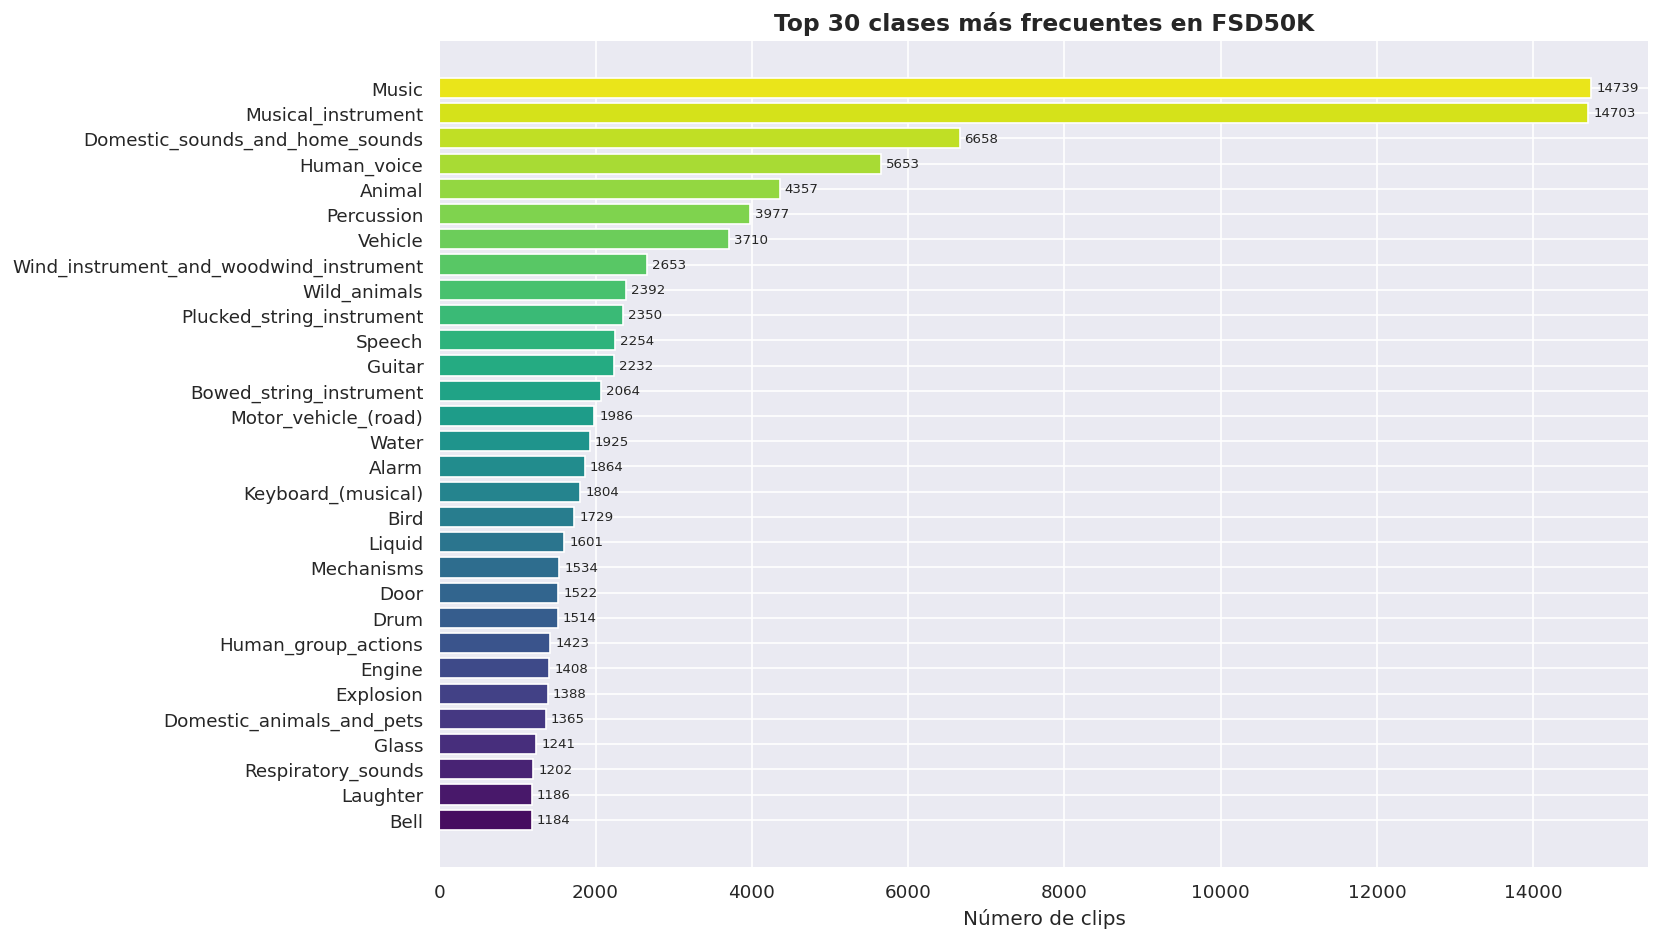

In [24]:
# Top 30 clases más frecuentes
top30 = label_counts.head(30)

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(top30['label'][::-1], top30['count'][::-1],
               color=sns.color_palette('viridis', 30))
ax.set_xlabel('Número de clips', fontsize=12)
ax.set_title('Top 30 clases más frecuentes en FSD50K', fontsize=14, fontweight='bold')
ax.bar_label(bars, padding=3, fontsize=8)
plt.tight_layout()
plt.show()

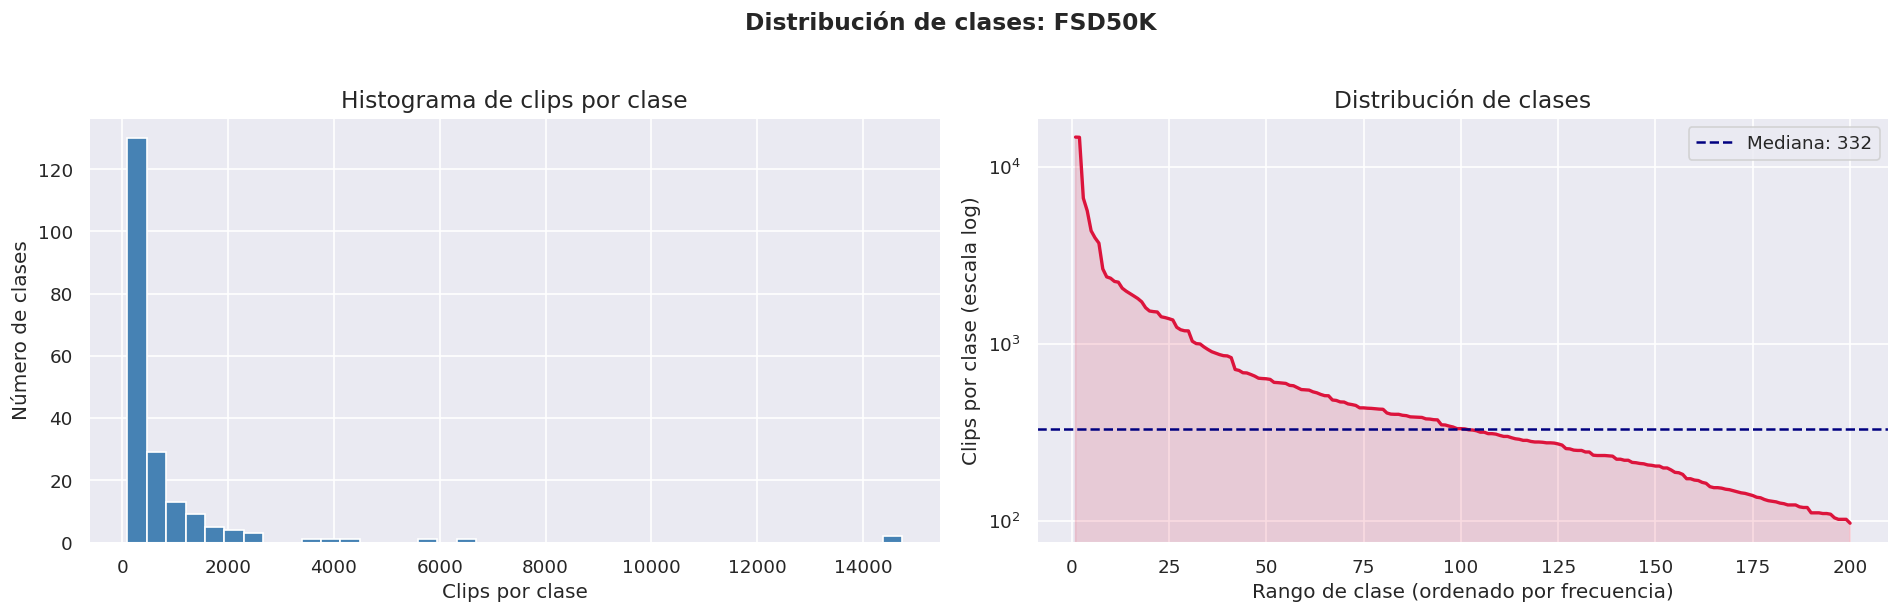


Estadísticas de clips por clase:
count      200.000000
mean       764.335000
std       1652.327684
min         97.000000
25%        204.000000
50%        331.500000
75%        631.250000
max      14739.000000


In [25]:
# Distribución completa (todas las 200 clases)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histograma de frecuencias
axes[0].hist(label_counts['count'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Clips por clase')
axes[0].set_ylabel('Número de clases')
axes[0].set_title('Histograma de clips por clase')

# Curva de distribución de clases
axes[1].plot(range(1, len(label_counts)+1), label_counts['count'].values,
             color='crimson', linewidth=2)
axes[1].fill_between(range(1, len(label_counts)+1), label_counts['count'].values,
                     alpha=0.15, color='crimson')
axes[1].set_yscale('log')
axes[1].set_xlabel('Rango de clase (ordenado por frecuencia)')
axes[1].set_ylabel('Clips por clase (escala log)')
axes[1].set_title('Distribución de clases')
axes[1].axhline(label_counts['count'].median(), color='navy', linestyle='--',
                label=f'Mediana: {label_counts["count"].median():.0f}')
axes[1].legend()

plt.suptitle('Distribución de clases: FSD50K', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\nEstadísticas de clips por clase:')
print(label_counts['count'].describe().to_string())

In [26]:
# Visualización interactiva con Plotly
fig_px = px.bar(
    label_counts.head(50),
    x='count', y='label',
    orientation='h',
    title='Top 50 clases más frecuentes (interactivo)',
    labels={'count': 'Clips', 'label': 'Clase'},
    color='count',
    color_continuous_scale='Viridis',
    height=900
)
fig_px.update_layout(yaxis={'categoryorder': 'total ascending'})
fig_px.show()

## **6. Análisis de etiquetas múltiples**

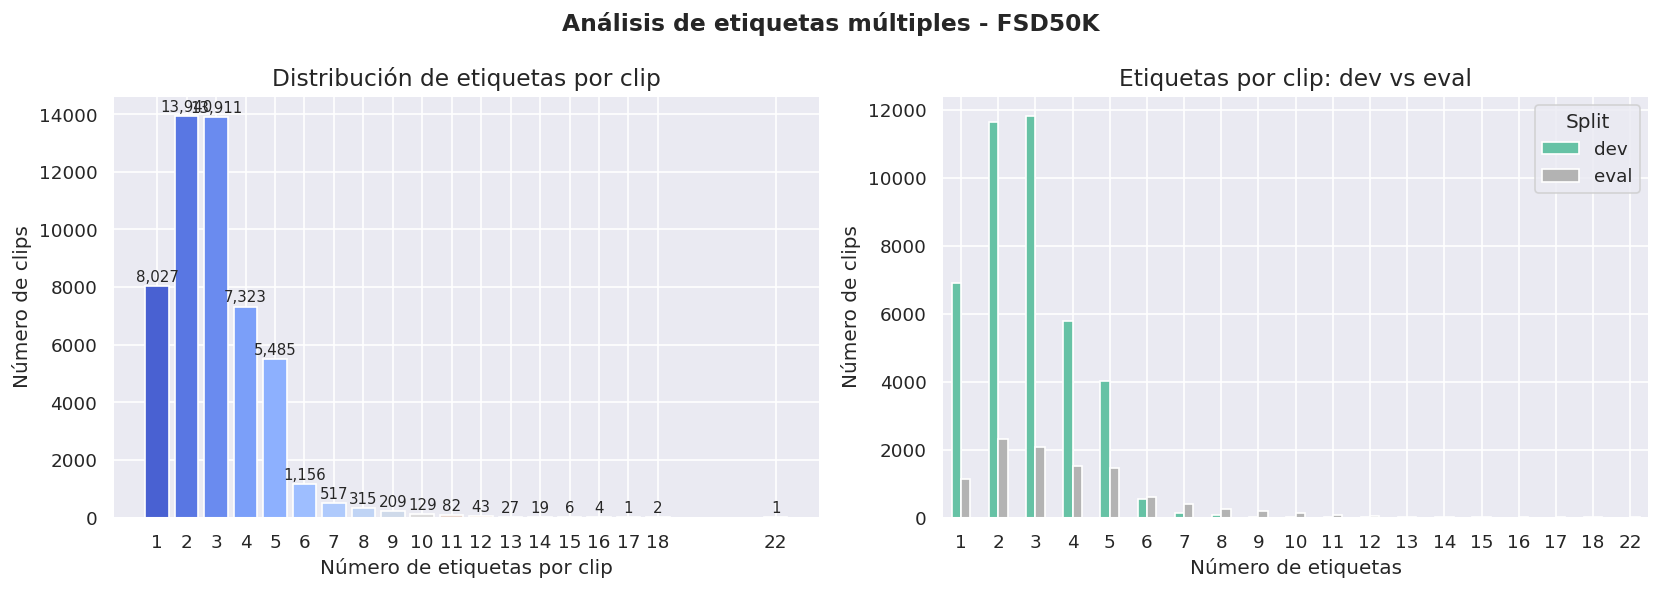

Clips con UNA sola etiqueta: 8,027 (15.68%)
Clips con MÚLTIPLES etiquetas: 43,170 (84.32%)


In [27]:
# Distribución del número de etiquetas por clip
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Conteo por número de etiquetas
nlabel_counts = df_all['n_labels'].value_counts().sort_index()

axes[0].bar(nlabel_counts.index, nlabel_counts.values,
            color=sns.color_palette('coolwarm', len(nlabel_counts)))
axes[0].set_xlabel('Número de etiquetas por clip')
axes[0].set_ylabel('Número de clips')
axes[0].set_title('Distribución de etiquetas por clip')
axes[0].set_xticks(nlabel_counts.index)
for i, (x, y) in enumerate(zip(nlabel_counts.index, nlabel_counts.values)):
    axes[0].text(x, y + 50, f'{y:,}', ha='center', va='bottom', fontsize=9)

# Por split
df_all.groupby(['split', 'n_labels']).size().unstack(fill_value=0).T.plot(
    kind='bar', ax=axes[1], colormap='Set2', edgecolor='white'
)
axes[1].set_xlabel('Número de etiquetas')
axes[1].set_ylabel('Número de clips')
axes[1].set_title('Etiquetas por clip: dev vs eval')
axes[1].legend(title='Split')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Análisis de etiquetas múltiples - FSD50K', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Clips con UNA sola etiqueta: {(df_all['n_labels']==1).sum():,} "
      f"({(df_all['n_labels']==1).mean()*100:.2f}%)")
print(f"Clips con MÚLTIPLES etiquetas: {(df_all['n_labels']>1).sum():,} "
      f"({(df_all['n_labels']>1).mean()*100:.2f}%)")

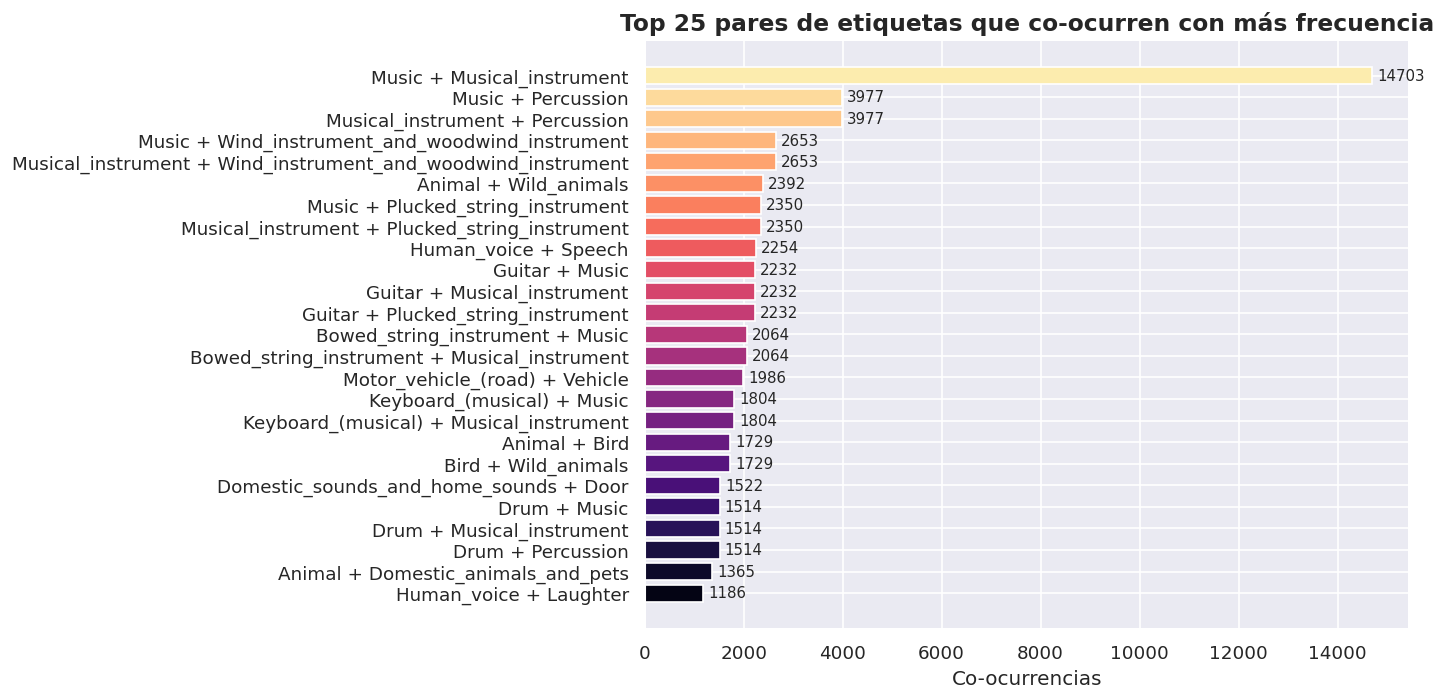

In [28]:
# Co-ocurrencia de etiquetas (top 20)
from itertools import combinations
from collections import Counter

# Calcular co-ocurrencias
cooc_counter = Counter()
for labels in df_all['label_list']:
    if len(labels) > 1:
        for pair in combinations(sorted(labels), 2):
            cooc_counter[pair] += 1

cooc_df = pd.DataFrame(
    [(a, b, c) for (a, b), c in cooc_counter.most_common(25)],
    columns=['label_a', 'label_b', 'count']
)

fig, ax = plt.subplots(figsize=(12, 6))
cooc_df['pair'] = cooc_df['label_a'] + ' + ' + cooc_df['label_b']
bars = ax.barh(cooc_df['pair'][::-1], cooc_df['count'][::-1],
               color=sns.color_palette('magma', len(cooc_df)))
ax.set_xlabel('Co-ocurrencias')
ax.set_title('Top 25 pares de etiquetas que co-ocurren con más frecuencia', fontweight='bold')
ax.bar_label(bars, padding=3, fontsize=9)
plt.tight_layout()
plt.show()

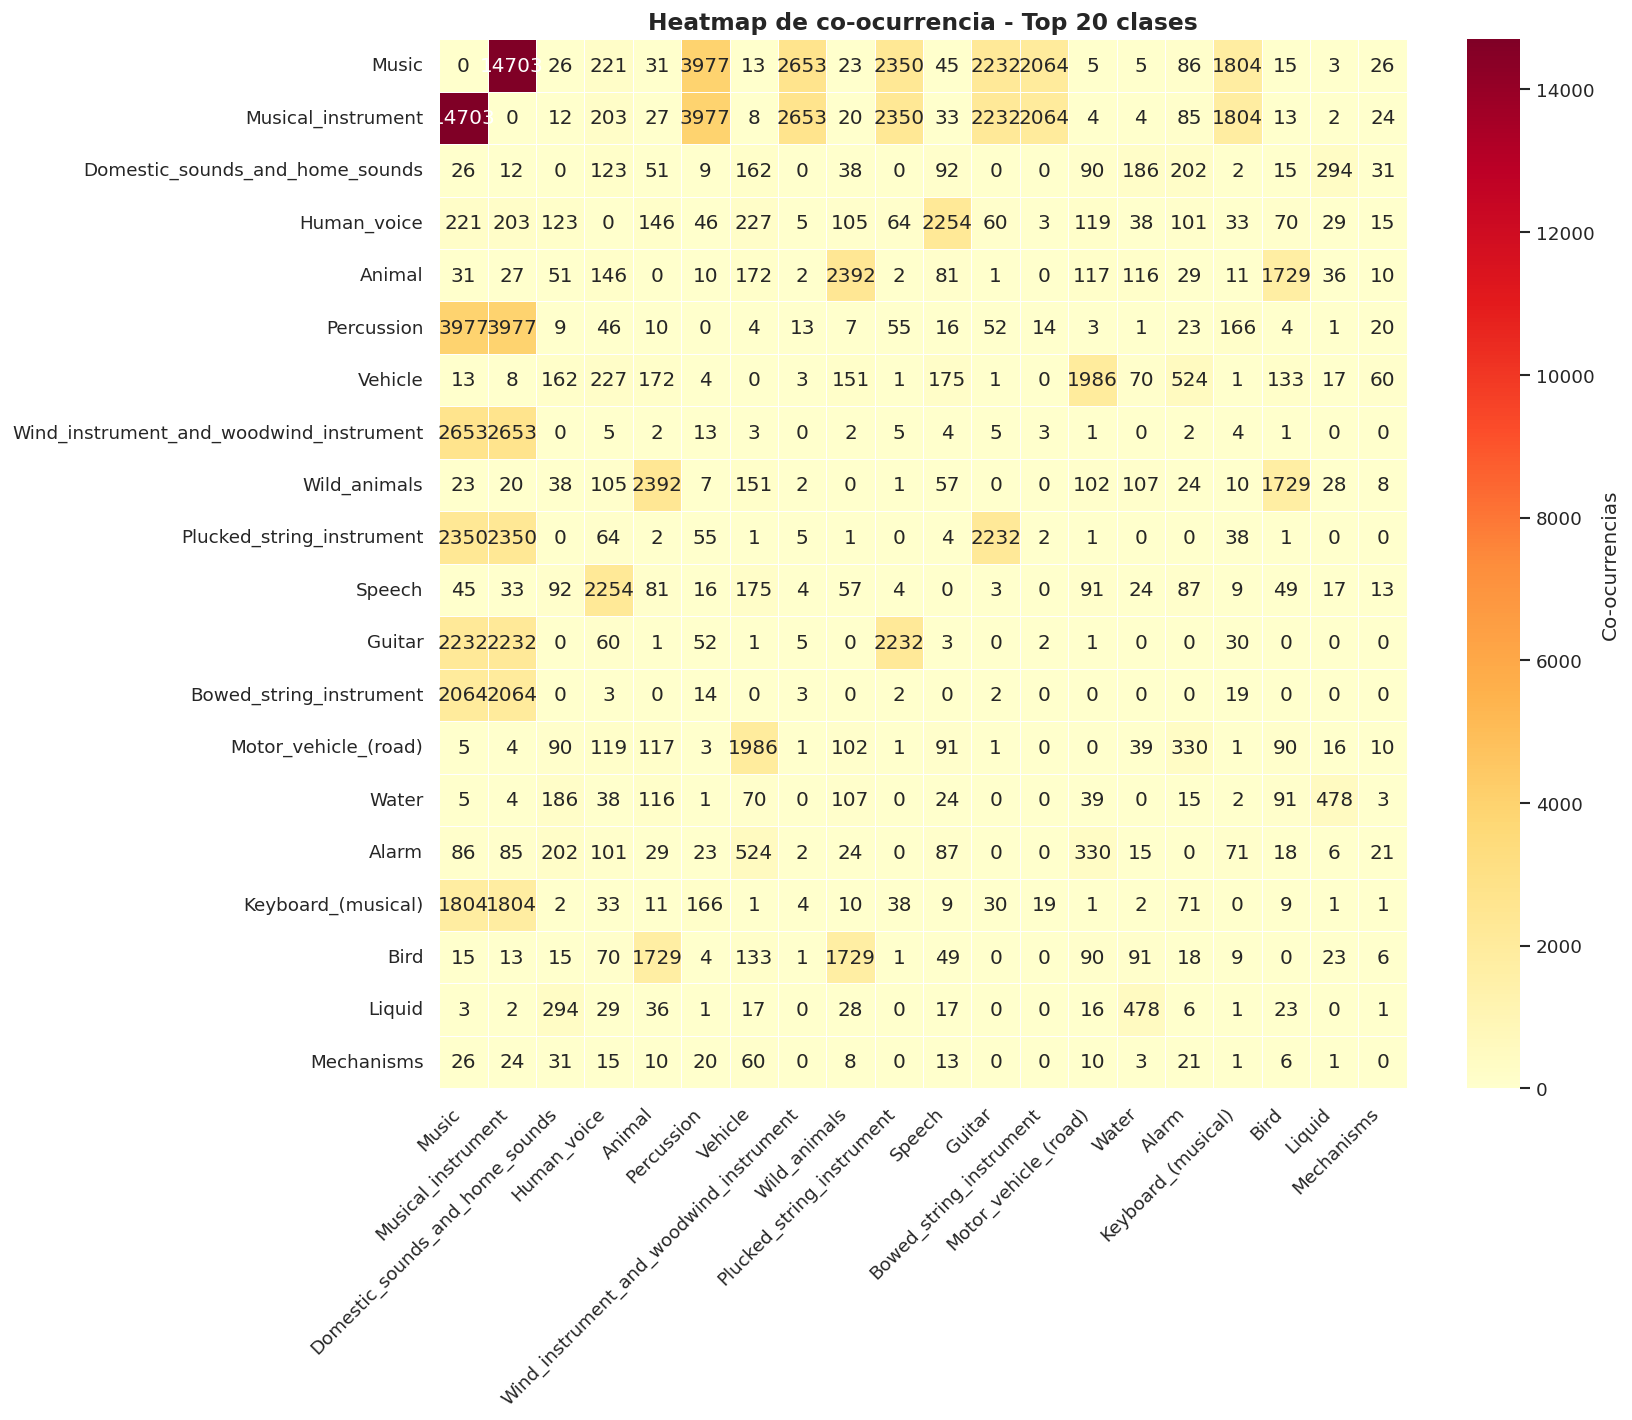

In [29]:
# Heatmap de co-ocurrencia (top 20 clases)
top20_labels = label_counts['label'].head(20).tolist()

# Matriz de co-ocurrencia
cooc_matrix = pd.DataFrame(0, index=top20_labels, columns=top20_labels)
for labels in df_all['label_list']:
    relevant = [l for l in labels if l in top20_labels]
    for a, b in combinations(relevant, 2):
        cooc_matrix.loc[a, b] += 1
        cooc_matrix.loc[b, a] += 1

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cooc_matrix, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Co-ocurrencias'})
ax.set_title('Heatmap de co-ocurrencia - Top 20 clases', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## **7. Exploración de splits dev/eval**

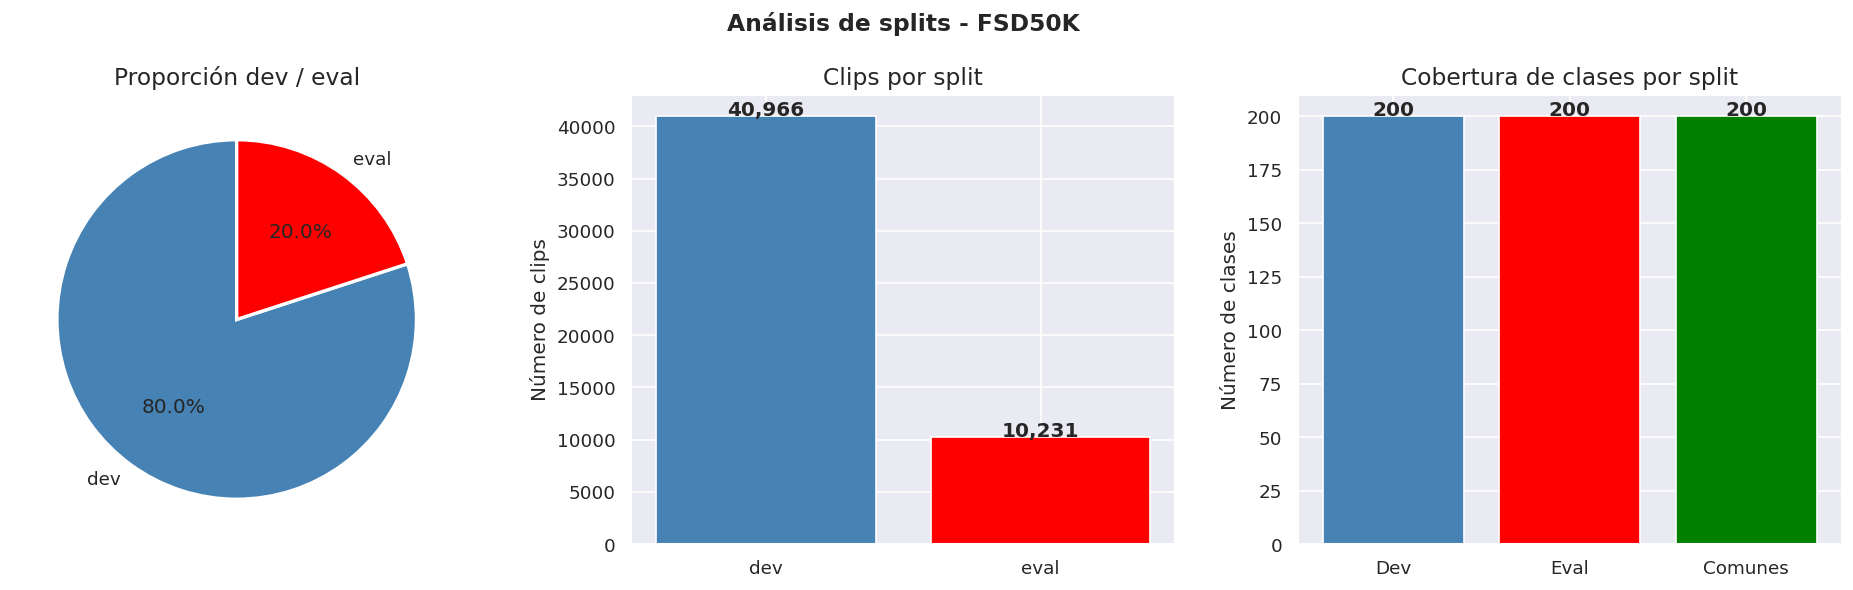

Clases solo en dev: 0
Clases solo en eval: 0
Clases en ambos: 200


In [30]:
split_counts = df_all['split'].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Pie chart
axes[0].pie(split_counts.values, labels=split_counts.index,
            autopct='%1.1f%%', colors=['steelblue', 'red'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Proporción dev / eval')

# Sub-splits del dev (train/val/test dentro del dev)
if 'split' in df_dev.columns and df_dev['split'].nunique() > 1:
    dev_splits = df_dev['split'].value_counts()
    axes[1].bar(dev_splits.index, dev_splits.values,
                color=sns.color_palette('Blues', len(dev_splits)))
    axes[1].set_title('Sub-splits dentro del dev set')
    axes[1].set_ylabel('Clips')
else:
    # Si no hay sub-splits, se muestra una comparación simple
    axes[1].bar(['dev', 'eval'], [len(df_dev), len(df_eval)],
                color=['steelblue', 'red'])
    axes[1].set_title('Clips por split')
    axes[1].set_ylabel('Número de clips')
    for i, v in enumerate([len(df_dev), len(df_eval)]):
        axes[1].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

# Clases cubiertas por cada split
if 'label_list' not in df_dev.columns:
    df_dev['label_list'] = df_dev['labels'].str.split(',')
if 'label_list' not in df_eval.columns:
    df_eval['label_list'] = df_eval['labels'].str.split(',')

dev_classes = set(df_dev['label_list'].explode())
eval_classes = set(df_eval['label_list'].explode())
common_classes = dev_classes & eval_classes

axes[2].bar(['Dev', 'Eval', 'Comunes'],
            [len(dev_classes), len(eval_classes), len(common_classes)],
            color=['steelblue', 'red', 'green'])
axes[2].set_title('Cobertura de clases por split')
axes[2].set_ylabel('Número de clases')
for i, v in enumerate([len(dev_classes), len(eval_classes), len(common_classes)]):
    axes[2].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

plt.suptitle('Análisis de splits - FSD50K', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Clases solo en dev: {len(dev_classes - eval_classes)}')
print(f'Clases solo en eval: {len(eval_classes - dev_classes)}')
print(f'Clases en ambos: {len(common_classes)}')

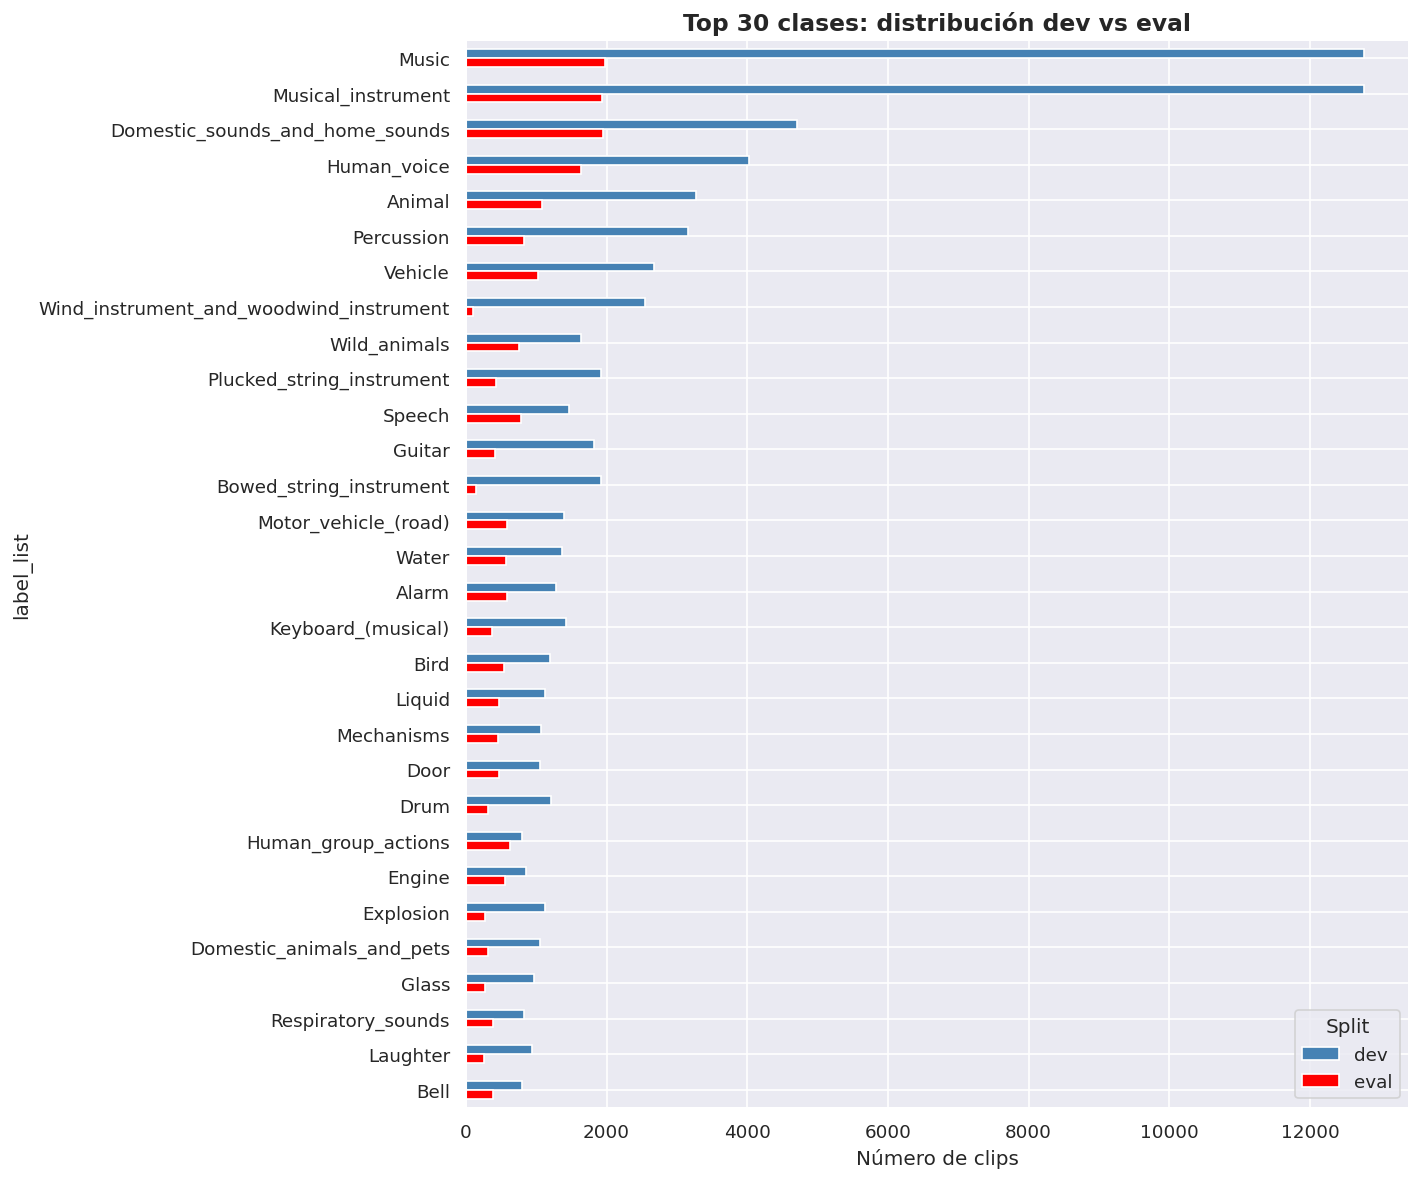

In [31]:
# Distribución de clases dev vs eval (comparativa)
dev_label_counts = df_dev['label_list'].explode().value_counts().rename('dev')
eval_label_counts = df_eval['label_list'].explode().value_counts().rename('eval')
split_label_df = pd.concat([dev_label_counts, eval_label_counts], axis=1).fillna(0)
split_label_df['total'] = split_label_df['dev'] + split_label_df['eval']
split_label_df = split_label_df.sort_values('total', ascending=False)

# Top 30
top30_split = split_label_df.head(30)[['dev', 'eval']]
top30_split.plot(kind='barh', figsize=(12, 10), color=['steelblue', 'red'], edgecolor='white')
plt.title('Top 30 clases: distribución dev vs eval', fontsize=14, fontweight='bold')
plt.xlabel('Número de clips')
plt.gca().invert_yaxis()
plt.legend(title='Split')
plt.tight_layout()
plt.show()

## **8. Visualización de formas de onda y espectrogramas**

- Esta sección requiere que los archivos de audio estén descargados.

In [32]:
# Función para visualizar un clip
def visualize_audio_clip(filepath, title='Audio Clip', sr_target=22050):
    """Muestra waveform, espectrograma mel y cromograma de un clip de audio."""
    y, sr = librosa.load(filepath, sr=sr_target, mono=True)
    duration = librosa.get_duration(y=y, sr=sr)

    fig, axes = plt.subplots(3, 1, figsize=(14, 9))

    # 1. Waveform
    librosa.display.waveshow(y, sr=sr, ax=axes[0], color='steelblue', alpha=0.8)
    axes[0].set_title(f'Forma de onda  |  Duración: {duration:.2f}s  |  SR: {sr} Hz')
    axes[0].set_xlabel('Tiempo (s)')

    # 2. Mel-espectrograma
    S_mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
    S_db = librosa.power_to_db(S_mel, ref=np.max)
    img = librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel',
                                   fmax=8000, ax=axes[1], cmap='magma')
    fig.colorbar(img, ax=axes[1], format='%+2.0f dB')
    axes[1].set_title('Mel-espectrograma')

    # 3. Cromograma
    chroma = librosa.feature.chroma_cqt(y=y, sr=sr)
    img2 = librosa.display.specshow(chroma, sr=sr, x_axis='time', y_axis='chroma',
                                    ax=axes[2], cmap='coolwarm')
    fig.colorbar(img2, ax=axes[2])
    axes[2].set_title('Cromograma')

    plt.suptitle(title, fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

    # Reproductor de audio
    display(Audio(data=y, rate=sr))

print('Función visualize_audio_clip definida.')

Función visualize_audio_clip definida.


In [33]:
# Comparativa de espectrogramas por categoría
# (solo si el audio está disponible)
if os.path.exists(DEV_AUDIO_DIR):
    CATEGORIES_TO_COMPARE = ['Speech', 'Music', 'Dog', 'Car', 'Rain']
    # Filtrar clips disponibles de esas categorías
    cat_clips = {}
    for cat in CATEGORIES_TO_COMPARE:
        mask = df_dev['label_list'].apply(lambda ls: cat in ls)
        candidates = df_dev[mask]['fname'].tolist()
        for fname in candidates:
            fpath = os.path.join(DEV_AUDIO_DIR, f'{fname}.wav')
            if os.path.exists(fpath):
                cat_clips[cat] = fpath
                break

    n_cats = len(cat_clips)
    if n_cats > 0:
        fig, axes = plt.subplots(1, n_cats, figsize=(5*n_cats, 4))
        if n_cats == 1:
            axes = [axes]

        for ax, (cat, fpath) in zip(axes, cat_clips.items()):
            y_c, sr_c = librosa.load(fpath, sr=22050, mono=True, duration=5.0)
            S = librosa.feature.melspectrogram(y=y_c, sr=sr_c, n_mels=64)
            S_db = librosa.power_to_db(S, ref=np.max)
            librosa.display.specshow(S_db, sr=sr_c, x_axis='time', y_axis='mel',
                                     ax=ax, cmap='viridis')
            ax.set_title(cat)
            ax.set_xlabel('Tiempo (s)')

        plt.suptitle('Espectrogramas por categoría', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
else:
    print('Audio no disponible para comparativa de espectrogramas.')

Audio no disponible para comparativa de espectrogramas.


## **9. Resumen y conclusiones**

In [34]:
# Panel resumen visual
fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=[
        'Clips por split',
        'Top 10 clases (dev)',
        'Etiquetas por clip',
        'Dist. clips por clase',
        'Clases por split',
        'Top 10 clases (eval)'
    ],
    vertical_spacing=0.18,
    horizontal_spacing=0.12
)

# 1. Clips por split
fig.add_trace(go.Bar(
    x=['Dev', 'Eval'], y=[len(df_dev), len(df_eval)],
    marker_color=['steelblue', 'red'], name='Clips por split', showlegend=False
), row=1, col=1)

# 2. Top 10 clases dev
top10_dev = df_dev['label_list'].explode().value_counts().head(10)
fig.add_trace(go.Bar(
    y=top10_dev.index[::-1], x=top10_dev.values[::-1],
    orientation='h', marker_color='steelblue', name='Top10 dev', showlegend=False
), row=1, col=2)

# 3. Etiquetas por clip
nlabel_vc = df_all['n_labels'].value_counts().sort_index()
fig.add_trace(go.Bar(
    x=nlabel_vc.index, y=nlabel_vc.values,
    marker_color='green', name='n_labels', showlegend=False
), row=1, col=3)

# 4. Distribución clips por clase
fig.add_trace(go.Scatter(
    x=list(range(1, len(label_counts)+1)),
    y=label_counts['count'].values,
    mode='lines', fill='tozeroy',
    line=dict(color='crimson'), name='Dist clases', showlegend=False
), row=2, col=1)
fig.update_yaxes(type='log', row=2, col=1)

# 5. Clases cubiertas
fig.add_trace(go.Bar(
    x=['Dev', 'Eval', 'Comunes'],
    y=[len(dev_classes), len(eval_classes), len(common_classes)],
    marker_color=['steelblue', 'red', 'green'], name='Clases', showlegend=False
), row=2, col=2)

# 6. Top 10 clases eval
top10_eval = df_eval['label_list'].explode().value_counts().head(10)
fig.add_trace(go.Bar(
    y=top10_eval.index[::-1], x=top10_eval.values[::-1],
    orientation='h', marker_color='red', name='Top10 eval', showlegend=False
), row=2, col=3)

fig.update_layout(
    height=700,
    title_text='<b>Resumen EDA FSD50K</b>',
    title_font_size=18,
    template='plotly_dark'
)
fig.show()

In [35]:
# Conclusiones
print('CONCLUSIONES DEL EDA: FSD50K')
print('=' * 60)

print(f"""
1. TAMAÑO DEL DATASET
   • {len(df_all):,} clips totales distribuidos en {len(df_vocab)} clases
   • Dev: {len(df_dev):,} clips ({len(df_dev)/len(df_all)*100:.2f}%)
   • Eval: {len(df_eval):,} clips ({len(df_eval)/len(df_all)*100:.2f}%)

2. DISTRIBUCIÓN DE CLASES
   • Clase más frecuente: '{label_counts.iloc[0]['label']}' ({label_counts.iloc[0]['count']:,} clips)
   • Clase menos frecuente: '{label_counts.iloc[-1]['label']}' ({label_counts.iloc[-1]['count']:,} clips)
   • Mediana clips/clase: {label_counts['count'].median():.0f}
   • Distribución muy desequilibrada (cola larga)

3. ETIQUETAS MÚLTIPLES
   • {(df_all['n_labels']==1).mean()*100:.2f}% de clips con una sola etiqueta
   • {(df_all['n_labels']>1).mean()*100:.2f}% de clips con múltiples etiquetas
   • Máximo: {df_all['n_labels'].max()} etiquetas en un solo clip
   • Media: {df_all['n_labels'].mean():.2f} etiquetas por clip

4. COBERTURA
   • {len(common_classes)} clases presentes en ambos splits
   • {len(dev_classes - eval_classes)} clases exclusivas del dev
   • {len(eval_classes - dev_classes)} clases exclusivas del eval

5. RECOMENDACIONES
   • Aplicar técnicas de balanceo de clases.
   • Tratar esto como un problema de clasificación multi-etiqueta.
   • Evaluar con métricas adecuadas.
""")

CONCLUSIONES DEL EDA: FSD50K

1. TAMAÑO DEL DATASET
   • 51,197 clips totales distribuidos en 200 clases
   • Dev: 40,966 clips (80.02%)
   • Eval: 10,231 clips (19.98%)

2. DISTRIBUCIÓN DE CLASES
   • Clase más frecuente: 'Music' (14,739 clips)
   • Clase menos frecuente: 'Tabla' (97 clips)
   • Mediana clips/clase: 332
   • Distribución muy desequilibrada (cola larga)

3. ETIQUETAS MÚLTIPLES
   • 15.68% de clips con una sola etiqueta
   • 84.32% de clips con múltiples etiquetas
   • Máximo: 22 etiquetas en un solo clip
   • Media: 2.99 etiquetas por clip

4. COBERTURA
   • 200 clases presentes en ambos splits
   • 0 clases exclusivas del dev
   • 0 clases exclusivas del eval

5. RECOMENDACIONES
   • Aplicar técnicas de balanceo de clases.
   • Tratar esto como un problema de clasificación multi-etiqueta.
   • Evaluar con métricas adecuadas.

